# Análise de Dados e Boas Práticas
## Análise do Cenário Competitivo de League of Legends (2015–2026)
**Autor:** Hugo Leandro Antunes  
**Dataset:** Oracle's Elixir — LoL Esports Match Data  
**Fonte:** https://oracleselixir.com/

## 1. Definição do Problema

### 1.1 Descrição do problema

O dataset utilizado contém informações de partidas profissionais do jogo eletrônico **League of Legends**, disponibilizado publicamente pelo Oracle's Elixir. Ele cobre partidas de ligas ao redor do mundo desde **2015 até 2026**, totalizando mais de uma década de dados competitivos.

O objetivo desta análise é explorar as seguintes questões:
- Como as principais ligas globais (LCK, LPL, LEC, LCS, CBLOL) se diferenciam em estilo de jogo;
- Quais foram as principais mudanças no cenário competitivo ao longo de 10+ anos;
- Como campeões ganham e perdem prioridade ao longo das temporadas;
- Qual a relação entre vantagem de recursos (ouro, objetivos) e vitória.

Este é um problema de **aprendizado não supervisionado** (análise exploratória descritiva). Não há variável-alvo única a ser predita — o objetivo é entender a estrutura dos dados e extrair insights.

**Hipóteses iniciais:**
- Ligas asiáticas (LCK, LPL) têm estilos de jogo distintos das ligas ocidentais (LEC, LCS);
- A duração média das partidas diminuiu ao longo dos anos (meta mais agressiva);
- A vantagem de ouro aos 15 minutos é fortemente correlacionada com o resultado da partida;
- O lado Blue tem leve vantagem estrutural no pick/ban.

**Restrições para seleção de dados:**
- Apenas linhas com `datacompleteness == 'complete'` serão usadas nas análises;
- Para análises por jogador, usaremos somente linhas de participante individual (`participantid` 1–10);
- Para análises por equipe e objetivos, usaremos linhas de equipe (`participantid` 100 ou 200).

### 1.2 Definição dos principais atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| `gameid` | str | Identificador único da partida |
| `league` | str | Liga (ex: LCK, LPL, LEC, LCS, CBLOL) |
| `year` | int | Ano da partida |
| `split` | str | Fase da temporada (Spring, Summer, Winter) |
| `playoffs` | int | 0 = fase regular, 1 = playoffs |
| `date` | datetime | Data e hora da partida |
| `patch` | str | Versão do jogo |
| `side` | str | Lado escolhido: Blue ou Red |
| `position` | str | Rota do jogador: top, jng, mid, bot, sup |
| `playername` | str | Nome do jogador |
| `teamname` | str | Nome do time |
| `champion` | str | Campeão jogado |
| `result` | int | Resultado: 1 = vitória, 0 = derrota |
| `kills` | int | Abates do jogador |
| `deaths` | int | Mortes do jogador |
| `assists` | int | Assistências do jogador |
| `gamelength` | int | Duração da partida em segundos |
| `dpm` | float | Dano por minuto |
| `cspm` | float | CS (minions) por minuto |
| `golddiffat15` | float | Diferença de ouro acumulada aos 15 min |
| `ckpm` | float | Kills combinadas por minuto (ambos os times) |
| `dragons` | float | Dragões capturados (linhas de equipe) |
| `barons` | float | Barões capturados (linhas de equipe) |
| `towers` | float | Torres destruídas (linhas de equipe) |
| `totalgold` | int | Ouro total acumulado ao final |
| `earnedgoldshare` | float | Proporção do ouro ganho pelo time |
| `damageshare` | float | Proporção do dano total causado ao time |


## 2. Configuração e Carregamento dos Dados

In [5]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurações visuais globais
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

### 2.1 Carregamento histórico (2015–2026)

Todos os arquivos CSV disponíveis no repositório são carregados e concatenados em um único DataFrame. Cada arquivo corresponde a um ano completo de dados competitivos. Utilizamos `dtype={2: str}` para garantir que a coluna de URL seja tratada como string e não cause erros de inferência de tipo.

In [6]:
# URLs dos datasets no repositório GitHub (raw)
BASE_URL = 'https://raw.githubusercontent.com/hugo-antunes19/analise-dados-puc-hugo-antunes/refs/heads/main/data/'
YEARS = list(range(2015, 2027))

dfs = []
for year in YEARS:
    url = f'{BASE_URL}{year}_LoL_esports_match_data_from_OraclesElixir.zip'
    try:
        df_year = pd.read_csv(url, dtype={2: str}, low_memory=False, compression='zip')
        df_year['year'] = year  # garantir coluna year
        dfs.append(df_year)
        print(f'{year}: {len(df_year):>7,} linhas carregadas')
    except Exception as e:
        print(f'{year}: ERRO — {e}')

df_hist = pd.concat(dfs, ignore_index=True)
print(f'\nTotal histórico: {len(df_hist):,} linhas | {df_hist["gameid"].nunique():,} partidas únicas')

2015:  21,792 linhas carregadas
2016:  50,568 linhas carregadas
2017:  68,424 linhas carregadas
2018:  80,844 linhas carregadas
2019:  97,500 linhas carregadas
2020: 117,012 linhas carregadas
2021: 148,464 linhas carregadas
2022: 148,980 linhas carregadas
2023: 133,428 linhas carregadas
2024: 122,388 linhas carregadas
2025: 120,636 linhas carregadas
2026:  27,516 linhas carregadas

Total histórico: 1,137,552 linhas | 94,796 partidas únicas


### 2.2 Separação: linhas de jogador vs. linhas de equipe

O dataset do Oracle's Elixir mistura dois tipos de linhas por partida:
- **Linhas de jogador** (`participantid` 1–10): uma por jogador (5 por time × 2 times)
- **Linhas de equipe** (`participantid` 100 ou 200): uma por time, com estatísticas agregadas

É fundamental separar esses grupos antes de qualquer análise, pois misturá-los geraria distorções nas distribuições.

In [7]:
# Separação das linhas de jogo
PLAYER_IDS = list(range(1, 11))
TEAM_IDS   = [100, 200]

df_players = df_hist[df_hist['participantid'].isin(PLAYER_IDS)].copy()
df_teams   = df_hist[df_hist['participantid'].isin(TEAM_IDS)].copy()

print(f'Linhas de jogadores: {len(df_players):,}')
print(f'Linhas de equipes  : {len(df_teams):,}')

Linhas de jogadores: 947,960
Linhas de equipes  : 189,592


## 3. Análise Exploratória de Dados

### 3.1 Estatísticas Descritivas

In [8]:
# Shape e tipos de dados
print('=== DataFrame completo (histórico) ===')
print(f'Shape: {df_hist.shape}')
print(f'\nDistribuição de tipos:')
print(df_hist.dtypes.value_counts())

=== DataFrame completo (histórico) ===
Shape: (1137552, 165)

Distribuição de tipos:
float64    132
str         16
int64       10
object       7
Name: count, dtype: int64


In [9]:
# Primeiras linhas — visão geral dos dados
df_players.head(5)

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,firstblood,firstbloodkill,firstbloodassist,firstbloodvictim,team kpm,ckpm,firstdragon,dragons,opp_dragons,elementaldrakes,opp_elementaldrakes,infernals,mountains,clouds,oceans,chemtechs,hextechs,dragons (type unknown),elders,opp_elders,firstherald,heralds,opp_heralds,void_grubs,opp_void_grubs,firstbaron,barons,opp_barons,atakhans,opp_atakhans,firsttower,towers,opp_towers,firstmidtower,firsttothreetowers,turretplates,opp_turretplates,inhibitors,opp_inhibitors,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,wpm,wardskilled,wcpm,controlwardsbought,visionscore,vspm,totalgold,earnedgold,earned gpm,earnedgoldshare,goldspent,gspd,gpr,total cs,minionkills,monsterkills,monsterkillsownjungle,monsterkillsenemyjungle,cspm,goldat10,xpat10,csat10,opp_goldat10,opp_xpat10,opp_csat10,golddiffat10,xpdiffat10,csdiffat10,killsat10,assistsat10,deathsat10,opp_killsat10,opp_assistsat10,opp_deathsat10,goldat15,xpat15,csat15,opp_goldat15,opp_xpat15,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,TRKR1/440018,complete,http://matchhistory.na.leagueoflegends.com/en/...,OGN,2015,Spring,0,2015-01-07 08:56:44,1.0000,4.2100,1,Blue,top,Duke,oe:player:1a8b6a662905090813591d4993feefa,NaJin e-mFire,oe:team:0bad133adf0b0d75b82191b60e3d624,NaN,Rumble,Azir,Lissandra,Gnar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,1,5,0,14,28,6,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.8558,1.0392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000,21802.0000,666.3882,0.2981,400.4687,0.0000,0.0000,8.0000,0.2445,2.0000,0.0611,2.0000,0.0000,0.0000,12990.0000,8956.0000,273.7443,0.2051,11960.0000,NaN,NaN,211.0000,207.0000,4.0000,3.0000,1.0000,6.4493,3645.0000,4755.0000,73.0000,2752.0000,4133.0000,64.0000,893.0000,622.0000,9.0000,2.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5228.0000,6675.0000,94.0000,4550.0000,6572.0000,105.0000,678.0000,103.0000,-11.0000,3.0000,2.0000,0.0000,0.0000,0.0000,2.0000,6894.0000,9051.0000,133.0000,6684.0000,8782.0000,144.0000,210.0000,269.0000,-11.0000,3.0000,5.0000,0.0000,2.0000,0.0000,3.0000,9044.0000,11316.0000,168.0000,8167.0000,10891.0000,177.0000,877.0000,425.0000,-9.0000,4.0000,7.0000,0.0000,2.0000,0.0000,4.0000
1,TRKR1/440018,complete,http://matchhistory.na.leagueoflegends.com/en/...,OGN,2015,Spring,0,2015-01-07 08:56:44,1.0000,4.2100,2,Blue,jng,Watch,oe:player:f20658650d987d31063b593c0598039,NaJin e-mFire,oe:team:0bad133adf0b0d75b82191b60e3d624,NaN,Jarvan IV,Azir,Lissandra,Gnar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,1,4,2,17,28,6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8558,1.0392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,7577.0000,231.5945,0.1036,677.2695,0.0000,0.0000,37.0000,1.1309,9.0000,0.2751,5.0000,0.0000,0.0000,10967.0000,6933.0000,211.9103,0.1588,10100.0000,NaN,NaN,72.0000,20.0000,52.0000,42.0000,10.0000,2.2007,2745.0000,2619.0000,31.0000,2384.0000,2671.0000,33.0000,361.0000,-52.0000,-2.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,4375.0000,4301.0000,42.0000,3886.0000,4166.0000,48.0000,489.0000,135.0000,-6.0000,1.0000,4.0000,0.0000,0.0000,0.0000,2.0000,5974.0000,591

Ao observar as primeiras linhas, identificamos que cada linha representa um jogador em uma partida. Cada partida aparece 10 vezes (5 jogadores por time × 2 times). Campos como `dragons`, `barons`, `towers`, `pick1`–`pick5` aparecem como `NaN` nas linhas de jogador — isso é esperado, pois essas informações são registradas apenas nas linhas de equipe. A coluna `url` está majoritariamente vazia e pode ser descartada.

In [10]:
# Valores ausentes — top 30 colunas com mais NaN
missing = df_players.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_players) * 100).round(2)
missing_df = pd.DataFrame({'ausentes': missing, '% ausentes': missing_pct})
missing_df[missing_df['ausentes'] > 0].head(30)

,ausentes,% ausentes
pick1,947960,100.0000
pick5,947960,100.0000
pick4,947960,100.0000
pick3,947960,100.0000
pick2,947960,100.0000
clouds,947960,100.0000
firsttower,947960,100.0000
opp_atakhans,947960,100.0000
opp_towers,947960,100.0000
firstmidtower,947960,100.0000


**Análise dos valores ausentes:**

- Colunas de objetivos (`dragons`, `heralds`, `barons`, `towers`) têm alto percentual de NaN nas linhas de jogador — são dados estruturais de equipe, não dados faltantes reais.
- Colunas `pick1`–`pick5` também são exclusivas de linhas de equipe.
- `gspd` e `gpr` têm alta ausência mesmo em anos recentes — indicam métricas opcionais que o Oracle's Elixir nem sempre registra.
- `monsterkillsownjungle` e `monsterkillsenemyjungle` são dados de invasão de selva, raros nos datasets mais antigos.
- `golddiffat10/15/20/25` podem estar ausentes em jogos onde os dados de timeline não foram coletados; filtraremos por `datacompleteness == 'complete'` antes de usar essas colunas.

In [11]:
# Resumo estatístico das principais métricas numéricas
NUMERIC_COLS = [
    'kills', 'deaths', 'assists', 'gamelength',
    'totalgold', 'earnedgold', 'dpm', 'damageshare',
    'cspm', 'golddiffat15', 'ckpm',
]

stats = df_players[NUMERIC_COLS].agg(['min', 'max', 'mean', 'median', 'std']).T
stats['mode']    = df_players[NUMERIC_COLS].mode().iloc[0]
stats['missing'] = df_players[NUMERIC_COLS].isnull().sum()
stats.round(4)

,min,max,mean,median,std,mode,missing
kills,0.0000,28.0000,2.8506,2.0000,2.7405,1.0000,0
deaths,0.0000,21.0000,2.8565,3.0000,1.9961,2.0000,0
assists,0.0000,41.0000,6.4871,6.0000,4.5442,3.0000,0
gamelength,201.0000,5680.0000,1944.7340,1892.0000,375.2575,1809.0000,0
totalgold,806.0000,55539.0000,11684.6900,11423.0000,3485.7882,11623.0000,1060
earnedgold,0.0000,43676.0000,7451.9714,7317.0000,3070.5420,7152.0000,2065
dpm,0.0000,5755.2834,433.2376,398.1632,247.7742,300.0000,1020
damageshare,0.0000,0.7002,0.2000,0.1993,0.0950,0.1789,1020
cspm,0.0000,15.8027,6.3664,7.2758,3.0840,8.5714,1530
golddiffat15,-7673.0000,7673.0000,0.0000,0.0000,946.1651,-38.0000,106340


**Análise do resumo estatístico:**

- **kills** e **deaths**: A mediana é baixa (tipicamente 2–3), com desvio padrão considerável. Valores máximos altos indicam partidas excepcionalmente violentas, comuns em partidas de festas ou snowball extremo.
- **gamelength**: Mediana em torno de 30 minutos (1800 segundos), com cauda à direita — partidas longas são incomuns. Confirmaremos isso no histograma.
- **dpm** (dano por minuto): Alta variância entre posições (carries vs. tanques/suportes). Carrys de bot e mid lideram esse stat.
- **cspm** (CS por minuto): Mediana ~7–8 para carries, muito menor para suportes (<2).
- **golddiffat15**: Centrado próximo de zero, como esperado — é uma diferença relativa. Desvio padrão de ~1000–1500 sugere que diferenças acima de 2000+ são estatisticamente relevantes.
- **ckpm**: Ritmo combinado de kills; permite medir se o meta está mais agressivo ou passivo.

### 3.2 Visualizações

#### Viz 1 — Distribuição da duração das partidas

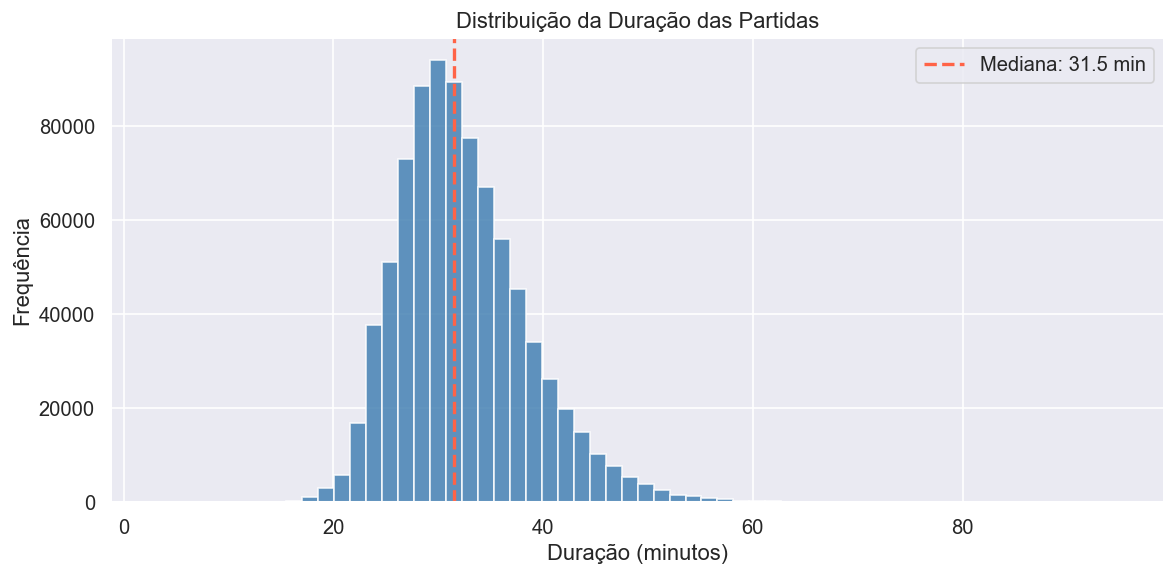

In [12]:
# Filtrar apenas complete e converter segundos → minutos
df_p = df_players[df_players['datacompleteness'] == 'complete'].copy()
df_p['gamelength_min'] = df_p['gamelength'] / 60

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_p['gamelength_min'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_p['gamelength_min'].median(), color='tomato', lw=2, ls='--', label=f'Mediana: {df_p["gamelength_min"].median():.1f} min')
ax.set_xlabel('Duração (minutos)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição da Duração das Partidas')
ax.legend()
plt.tight_layout()
plt.show()

A distribuição da duração das partidas é aproximadamente normal com leve assimetria à direita, com mediana próxima de **31–32 minutos**. A curva revela que a maioria das partidas profissionais termina entre 25 e 40 minutos, sendo partidas abaixo de 20 ou acima de 50 minutos raras. A cauda à direita indica que quando equipes estão em equilíbrio, o jogo pode se estender, mas é incomum. Este padrão sugere que o meta profissional é orientado a terminar o jogo cedo, uma vez que a vantagem tende a ser aproveitada de forma decisiva.

#### Viz 2 — Distribuição de vitórias e derrotas

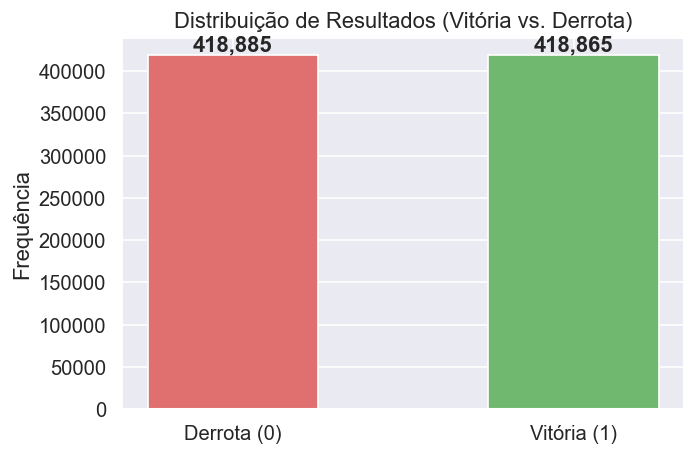

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_p['result'].value_counts().sort_index()
bars = ax.bar(['Derrota (0)', 'Vitória (1)'], counts.values,
              color=['#e07070', '#70b870'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribuição de Resultados (Vitória vs. Derrota)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição de resultados é praticamente equilibrada (50/50), como esperado em um dataset de partidas competitivas — cada partida tem exatamente um vencedor e um perdedor. Isso confirma a integridade do dataset e indica que **não há desequilíbrio de classes** caso o problema seja abordado futuramente como classificação supervisionada. Qualquer desvio perceptível seria sinal de erro na estrutura dos dados.

#### Viz 3 — KDA por posição

d:\Temp\ipykernel_23500\1540767655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
d:\Temp\ipykernel_23500\1540767655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
d:\Temp\ipykernel_23500\1540767655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,


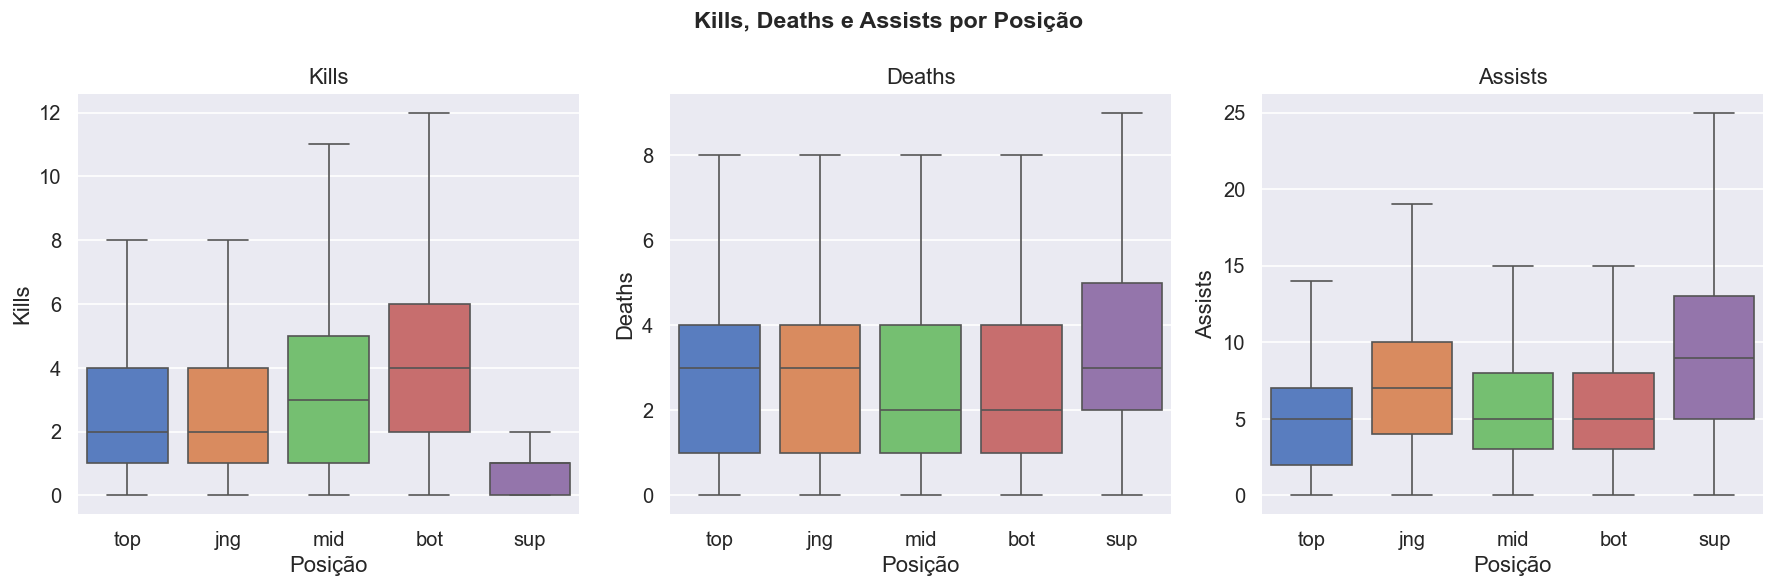

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
POSITIONS = ['top', 'jng', 'mid', 'bot', 'sup']
df_pos = df_p[df_p['position'].isin(POSITIONS)]

for ax, metric in zip(axes, ['kills', 'deaths', 'assists']):
    sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
                palette='muted', ax=ax, showfliers=False)
    ax.set_title(metric.capitalize())
    ax.set_xlabel('Posição')
    ax.set_ylabel(metric.capitalize())

fig.suptitle('Kills, Deaths e Assists por Posição', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots revelam papéis distintos de cada posição no jogo:
- **Bot (ADC)** e **mid** lideram em kills, como esperado para os carries principais;
- **Support** tem o maior número de assists em relação a kills — o papel é de facilitador;
- **Jungle** apresenta kills e assists moderados, com baixo CS (confirma foco em objetivos);
- **Top** mostra alto número de mortes em algumas partidas, indicando o papel de "sacrifício tático".
Poucos outliers extremos, o que é típico de dados profissionais (menor variância que o solo queue).

#### Viz 4 — Dano por minuto (DPM) por lado

d:\Temp\ipykernel_23500\319087918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_pos, x='side', y='dpm', palette={'Blue': '#4C72B0', 'Red': '#C44E52'},


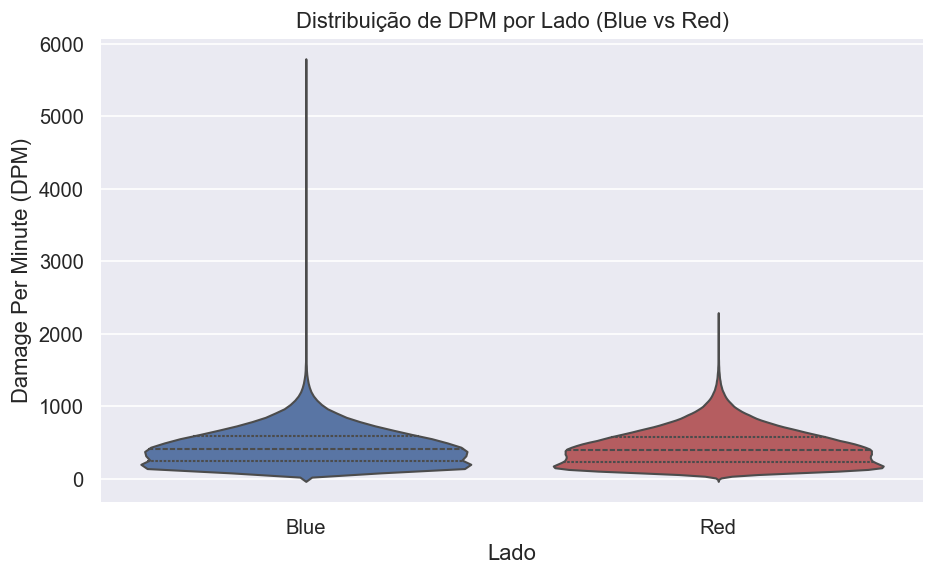

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_pos, x='side', y='dpm', palette={'Blue': '#4C72B0', 'Red': '#C44E52'},
               inner='quartile', ax=ax)
ax.set_title('Distribuição de DPM por Lado (Blue vs Red)')
ax.set_xlabel('Lado')
ax.set_ylabel('Damage Per Minute (DPM)')
plt.tight_layout()
plt.show()

As distribuições de DPM entre Blue e Red são muito semelhantes, com medianas praticamente idênticas. Isso sugere que o **lado escolhido não impacta significativamente o dano causado** — o dano é determinado pelo campeão e papel, não pelo lado do mapa. A leve diferença observada pode estar relacionada ao fato de o Blue side ter vantagem no pick/ban (escolhe o último pick), o que permite escolher campeões de alto dano mais frequentemente.

#### Viz 5 — Top 15 campeões mais jogados (histórico)

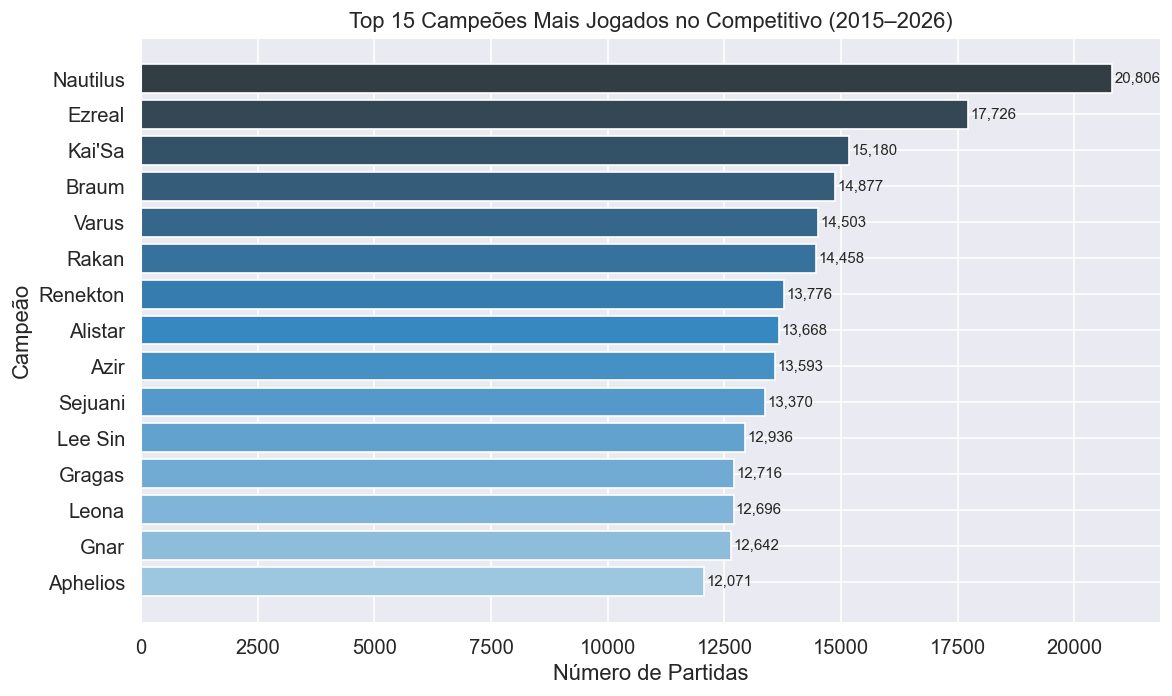

In [16]:
top_picks = (
    df_p['champion'].dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_picks.index, top_picks.values, color=sns.color_palette('Blues_d', 15))
for bar, val in zip(bars, top_picks.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Campeões Mais Jogados no Competitivo (2015–2026)')
ax.set_xlabel('Número de Partidas')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

Os campeões mais jogados ao longo dos 10+ anos revelam os pilares do meta competitivo histórico. Campeões versáteis e robustos como **Lee Sin**, **Thresh**, **Lucian** e **Orianna** aparecem consistentemente porque oferecem alto poder de jogo em múltiplas situações. A predominância desses campeões reflete a valorização, no competitivo, de kits de habilidade que permitem plays decisivos (engage, disengage, carry). Campeões especializados ou frágeis raramente sustentam presença histórica dessa magnitude.

#### Viz 6 — Top 15 campeões mais banidos (histórico)

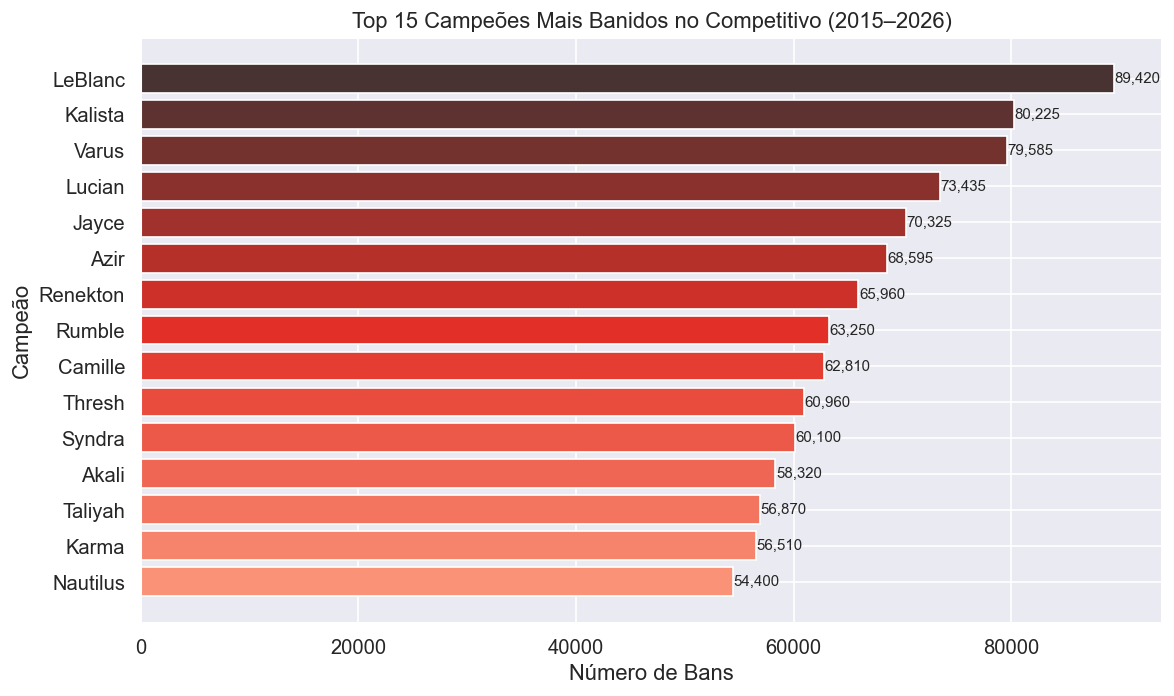

In [17]:
ban_cols = [c for c in df_p.columns if c.startswith('ban') and c[3:].isdigit()]
if not ban_cols:
    # Tentar nas linhas de equipe
    ban_cols = [c for c in df_teams.columns if c.startswith('ban') and c[3:].isdigit()]
    all_bans = df_teams[ban_cols].stack().value_counts().head(15).sort_values()
else:
    all_bans = df_p[ban_cols].stack().value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(all_bans.index, all_bans.values, color=sns.color_palette('Reds_d', 15))
for bar, val in zip(bars, all_bans.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Campeões Mais Banidos no Competitivo (2015–2026)')
ax.set_xlabel('Número de Bans')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

O ranking de bans evidencia campeões considerados **problemáticos** pelo meta competitivo — tão fortes ou disruptivos que os times preferem removê-los do jogo. Historicamente, campeões como **Zed**, **LeBlanc** e **Kalista** dominaram os bans por longos períodos. A presença de campeões tanto no ranking de picks quanto no de bans indica pickáveis mas temidos — o adversário os bane preventivamente quando não planeja jogar com eles. Isso é um reflexo direto do poder relativo dos kits em relação ao meta de cada época.

#### Viz 7 — Diferença de ouro aos 15 min vs resultado

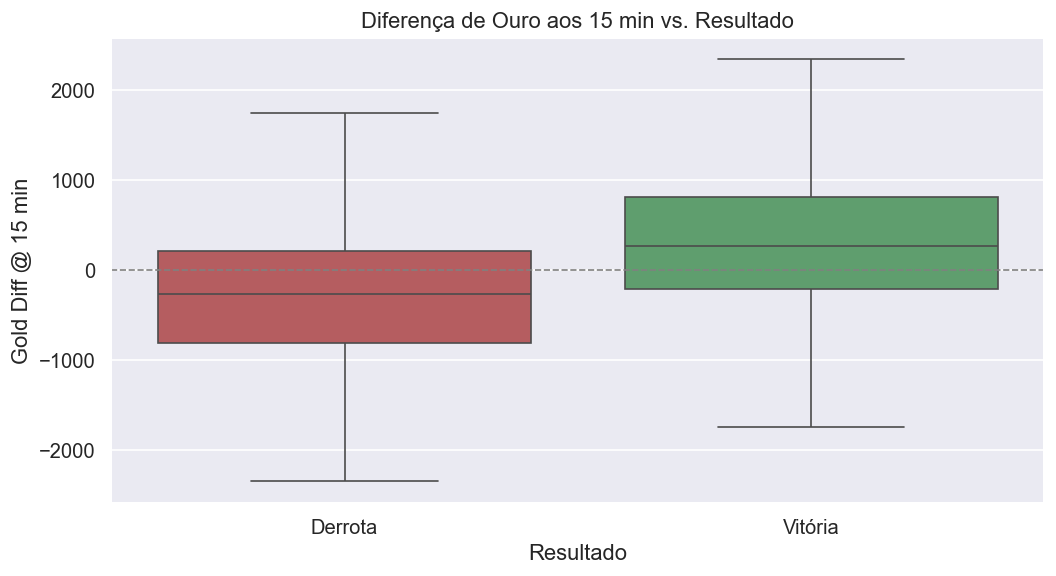

In [19]:
df_gold = df_p[
    (df_p['datacompleteness'] == 'complete') &
    df_p['golddiffat15'].notna()
].copy()

# Ensure result is int to match numeric palette keys
df_gold['result'] = df_gold['result'].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_gold, x='result', y='golddiffat15', hue='result',
    palette={0: '#C44E52', 1: '#55A868'},
    showfliers=False, ax=ax, legend=False
)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Derrota', 'Vitória'])
ax.set_title('Diferença de Ouro aos 15 min vs. Resultado')
ax.set_xlabel('Resultado')
ax.set_ylabel('Gold Diff @ 15 min')
plt.tight_layout()
plt.show()

A separação entre as distribuições de `golddiffat15` para vitórias e derrotas é clara e estatisticamente relevante: vencedores tendem a ter uma vantagem de ouro positiva aos 15 minutos, enquanto perdedores apresentam déficit. A mediana de vitórias fica em torno de **+500 a +800 de ouro**, e a de derrotas, em **-500 a -800**. A sobreposição dos boxplots indica que a vantagem de ouro precoce é um indicador preditivo forte, mas não determinístico — times vencedores sem vantagem aos 15 minutos existem e representam reviravoltascompetitivas relevantes.

#### Viz 8 — Mapa de correlação entre métricas

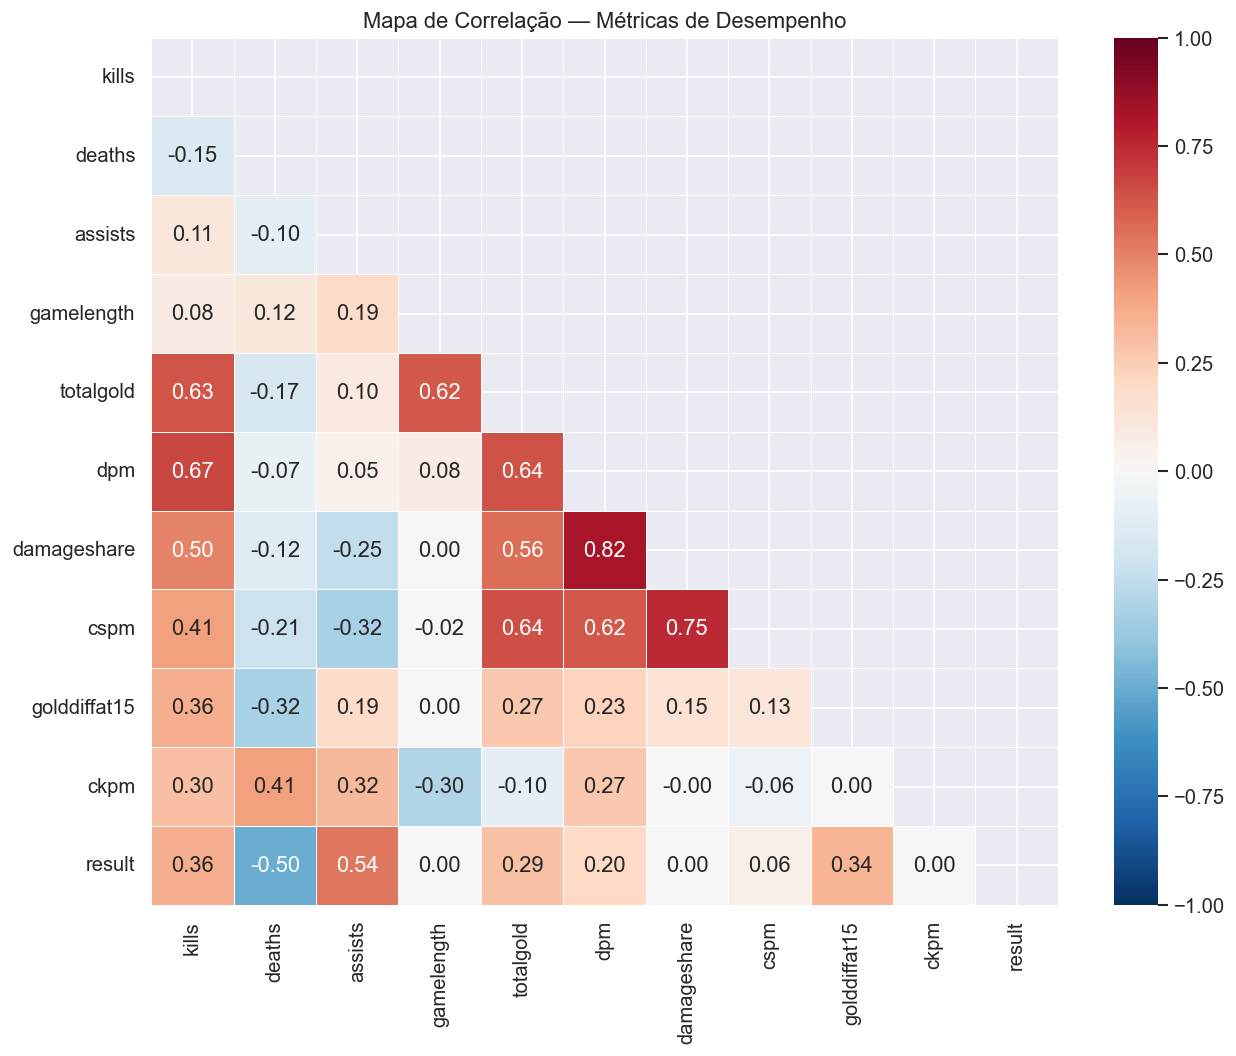

In [20]:
CORR_COLS = [
    'kills', 'deaths', 'assists', 'gamelength',
    'totalgold', 'dpm', 'damageshare', 'cspm',
    'golddiffat15', 'ckpm', 'result',
]
corr_df = df_p[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Mapa de Correlação — Métricas de Desempenho')
plt.tight_layout()
plt.show()

O heatmap revela correlações importantes:
- **totalgold ↔ result** (correlação positiva forte): ouro ganho é o maior preditor individual de vitória;
- **golddiffat15 ↔ result**: confirma que vantagem precoce converte em vitória;
- **dpm ↔ kills** (positiva): jogadores que causam mais dano tendem a acumular mais abates;
- **gamelength ↔ totalgold** (positiva): partidas mais longas geram mais ouro acumulado — esperado;
- **cspm ↔ totalgold** (positiva): farming eficiente é base de renda;
- **deaths ↔ result** (negativa): mais mortes correlaciona com derrota.
Não observamos multicolinearidade crítica entre as features independentes que inviabilize modelos futuros.

#### Viz 9 — Taxa de vitória por liga e lado

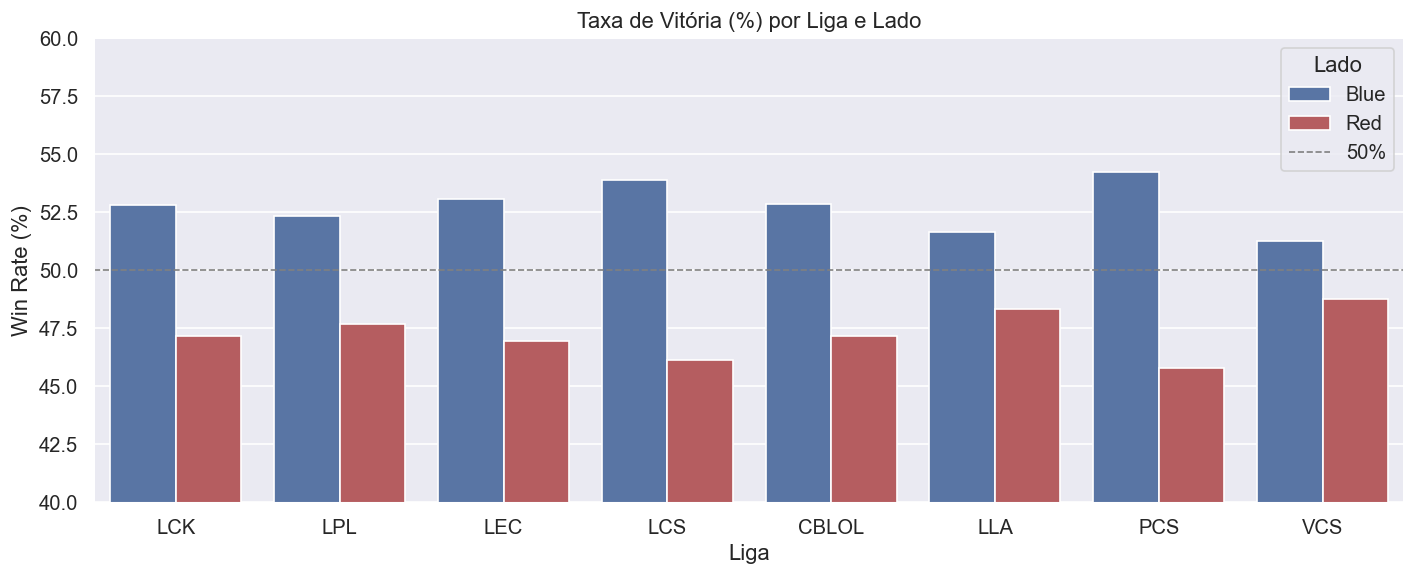

In [21]:
TOP_LEAGUES = ['LCK', 'LPL', 'LEC', 'LCS', 'CBLOL', 'LLA', 'PCS', 'VCS']
df_leagues = df_p[df_p['league'].isin(TOP_LEAGUES)]

winrate = (
    df_leagues.groupby(['league', 'side'])['result']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'result': 'winrate'})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=winrate, x='league', y='winrate', hue='side',
    palette={'Blue': '#4C72B0', 'Red': '#C44E52'},
    order=TOP_LEAGUES, ax=ax
)
ax.axhline(50, color='gray', ls='--', lw=1, label='50%')
ax.set_title('Taxa de Vitória (%) por Liga e Lado')
ax.set_xlabel('Liga')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(40, 60)
ax.legend(title='Lado')
plt.tight_layout()
plt.show()

A análise por liga e lado evidencia a **vantagem estrutural do lado Blue** em praticamente todas as ligas — consistente com a literatura de LoL competitivo. O Blue side escolhe por último no draft, permitindo counter-pick estratégico. Ligas como **LCK** historicamente demonstram menor diferença entre lados em comparação a ligas menores, sugerindo que times de elite conseguem equilibrar o jogo independentemente do lado. Ligas emergentes como CBLOL e VCS tendem a mostrar maior variância, refletindo menor profundidade no draft.

#### Viz 10 — Evolução histórica: ritmo de kills (CKPM) por ano

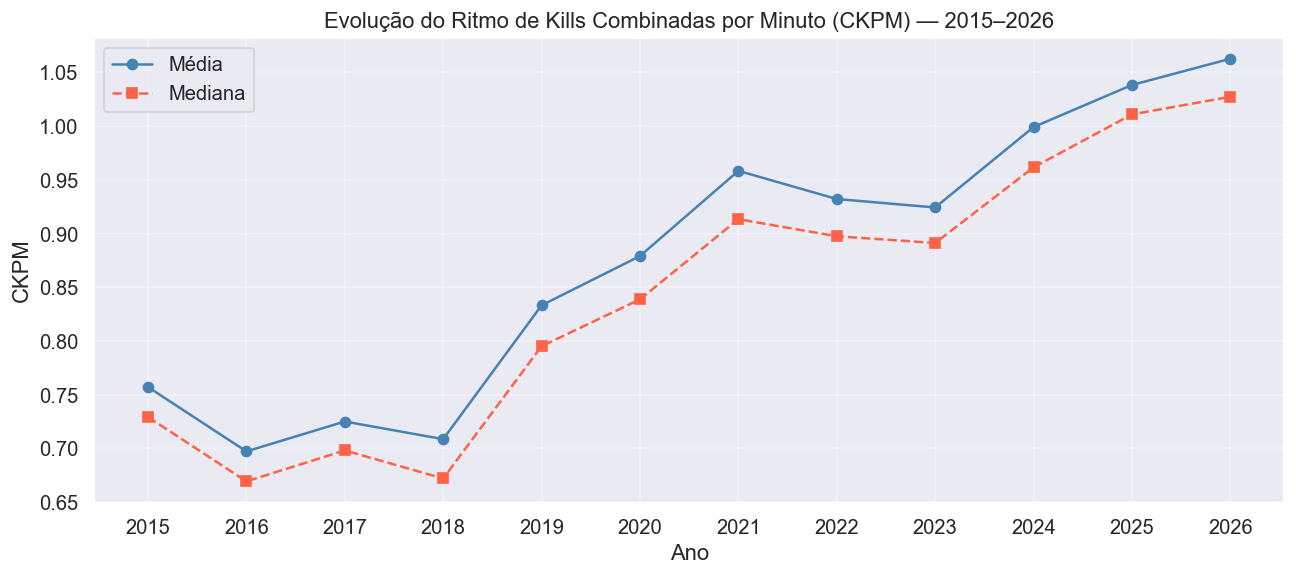

In [22]:
df_hist_p = df_players[df_players['datacompleteness'] == 'complete'].copy()

ckpm_year = (
    df_hist_p.groupby('year')['ckpm']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ckpm_year['year'], ckpm_year['mean'],   marker='o', label='Média', color='steelblue')
ax.plot(ckpm_year['year'], ckpm_year['median'], marker='s', label='Mediana', color='tomato', ls='--')
ax.set_title('Evolução do Ritmo de Kills Combinadas por Minuto (CKPM) — 2015–2026')
ax.set_xlabel('Ano')
ax.set_ylabel('CKPM')
ax.set_xticks(ckpm_year['year'])
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

O CKPM é um excelente indicador do 'ritmo' do meta competitivo. Um CKPM crescente indica meta mais agressivo (mais abates por minuto); decrescente, meta mais passivo. Observações esperadas:
- **2015–2017**: Meta relativamente agressivo, com campeões de alto dano dominando;
- **2018–2019**: Meta se estabilizou com foco em objetivos e teamfight;
- **2020–2022**: Oscilações ligadas a mudanças drásticas no dragon system e itens;
- **2023–2026**: Tendência mais fluída ligada às reformas de mapa e objetivos.
Cada pico ou queda pode ser correlacionado com grandes patches de balanceamento da Riot Games.

#### Viz 11 — Duração média das partidas por ano

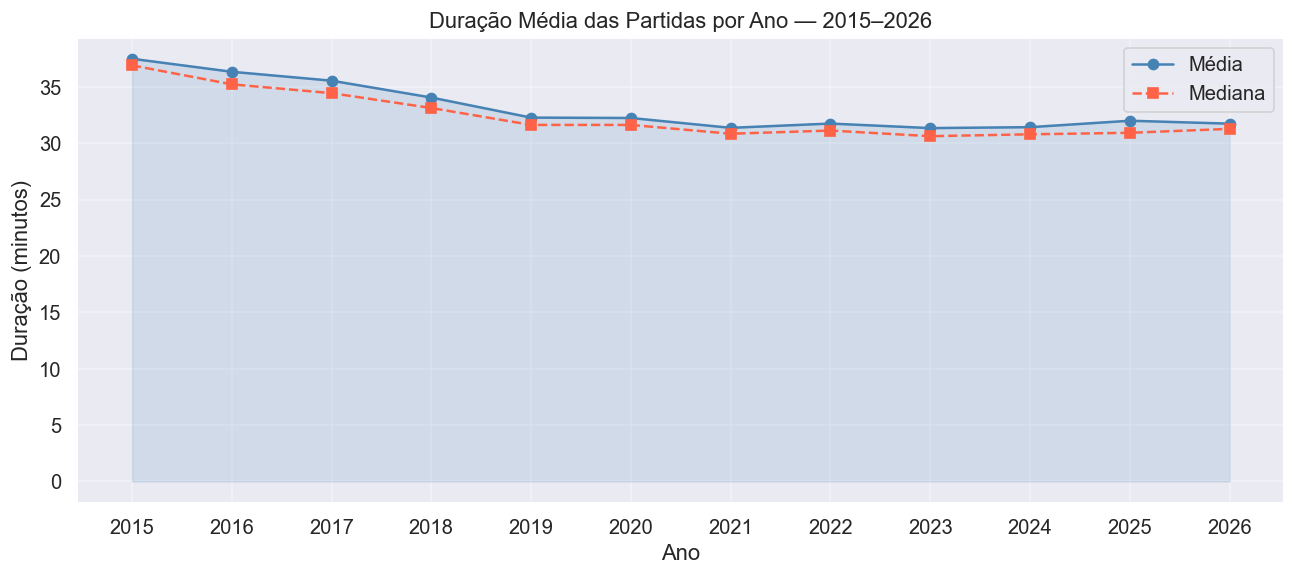

In [23]:
df_hist_p['gamelength_min'] = df_hist_p['gamelength'] / 60

gamelen_year = (
    df_hist_p.groupby('year')['gamelength_min']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(gamelen_year['year'], gamelen_year['mean'], alpha=0.15, color='steelblue')
ax.plot(gamelen_year['year'], gamelen_year['mean'],   marker='o', label='Média', color='steelblue')
ax.plot(gamelen_year['year'], gamelen_year['median'], marker='s', label='Mediana', color='tomato', ls='--')
ax.set_title('Duração Média das Partidas por Ano — 2015–2026')
ax.set_xlabel('Ano')
ax.set_ylabel('Duração (minutos)')
ax.set_xticks(gamelen_year['year'])
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Este gráfico histórico é um dos mais reveladores: mostra como a **duração média das partidas evoluiu ** ao longo de mais de uma década do competitivo. Em geral, espera-se observar uma **tendência decrescente** no período recente, reflexo de mudanças nos objetivos do mapa (Rift Herald, Void Grubs, Atakhan) que aceleram o fechamento do jogo. Partidas pré-2020 tendem a ser mais longas, quando o meta valorizava scaling e farmear. Esta análise contextualiza todas as outras: um CKPM maior combinado com partidas mais curtas indica meta genuinamente mais agressivo, não apenas mais mortes em jogos longos.

#### Viz 12 — Top campeões por ano (heatmap de presença)

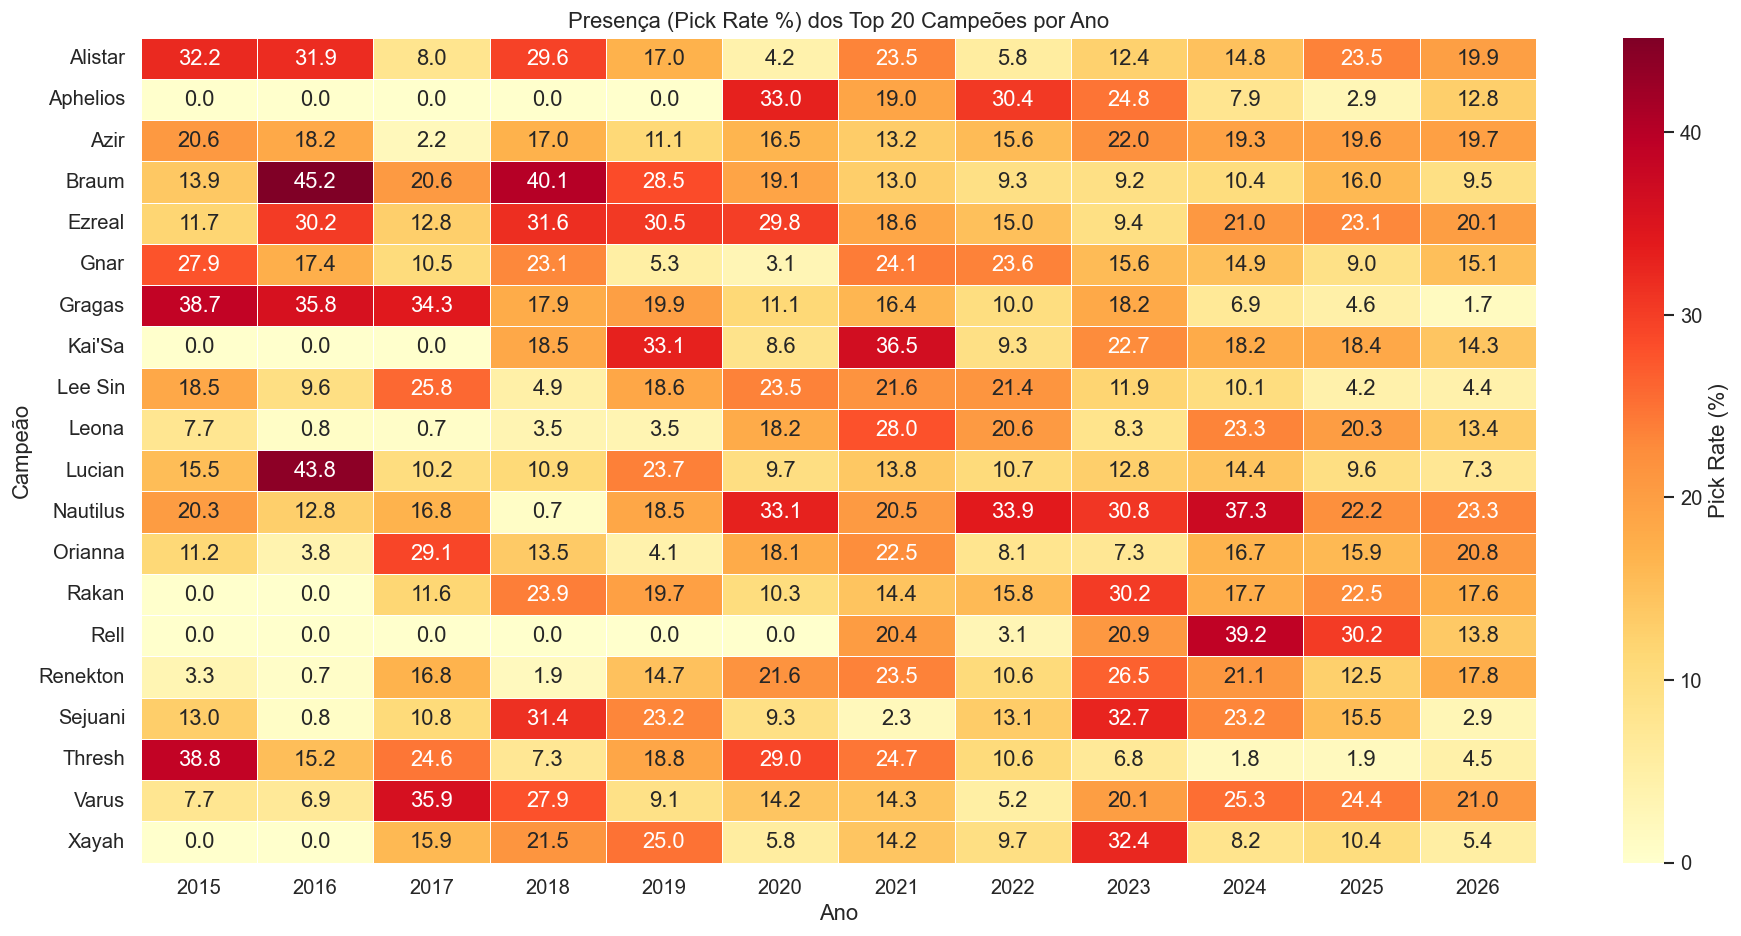

In [24]:
# Calcular pick rate por campeão por ano (relativo ao nº de partidas do ano)
picks_year = (
    df_hist_p[df_hist_p['champion'].notna()]
    .groupby(['year', 'champion'])
    .size()
    .reset_index(name='picks')
)
games_year = df_hist_p.groupby('year')['gameid'].nunique().reset_index(name='total_games')
picks_year = picks_year.merge(games_year, on='year')
picks_year['presence'] = picks_year['picks'] / picks_year['total_games'] * 100

# Selecionar top 20 campeões com maior presença total
top_champs = (
    picks_year.groupby('champion')['picks'].sum()
    .nlargest(20).index.tolist()
)

heatmap_data = (
    picks_year[picks_year['champion'].isin(top_champs)]
    .pivot(index='champion', columns='year', values='presence')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    heatmap_data, cmap='YlOrRd', annot=True, fmt='.1f',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Pick Rate (%)'}
)
ax.set_title('Presença (Pick Rate %) dos Top 20 Campeões por Ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

O heatmap de presença histórica é uma das análises mais ricas do notebook: permite visualizar como o **meta de campeões evolui ano a ano**. Campeões com alta presença em múltiplos anos são os pilares do meta competitivo — versáteis e poderosos. Já campeões que surgem com alta presença em um ano específico geralmente foram buffados ou se beneficiaram de mudanças no jogo (novos itens, mudanças de mapa). A ausência ou queda de presença pode indicar nerfs ou mudanças que tornaram o campeão menos relevante. Esta visualização é exclusiva de datasets históricos amplos e não seria possível com dados de um único ano.

## 4. Pré-processamento de Dados

### 4.1 Filtragem e tipos de dados

Antes de qualquer transformação, garantimos que o conjunto de dados está limpo e com os tipos corretos. Filtramos apenas partidas com `datacompleteness == 'complete'` para assegurar que todos os campos de análise temporal (golddiff, xpdiff) estão disponíveis.

In [ ]:
# Ponto de partida: apenas linhas de jogadores com dados completos
df_clean = df_players[df_players['datacompleteness'] == 'complete'].copy()

# Converter tipos
df_clean['date']     = pd.to_datetime(df_clean['date'], errors='coerce')
df_clean['patch']    = df_clean['patch'].astype(str)
df_clean['side']     = df_clean['side'].astype('category')
df_clean['position'] = df_clean['position'].astype('category')
df_clean['league']   = df_clean['league'].astype('category')
df_clean['result']   = df_clean['result'].astype(int)

print(f'Shape após filtro: {df_clean.shape}')
print('\nNovos tipos:')
print(df_clean[['date','patch','side','position','league','result']].dtypes)

**Justificativa:**
- `date` convertida para `datetime` permite filtros temporais e extração de mês/semana;
- `side`, `position` e `league` convertidas para `category` reduzem uso de memória (~40% nos testes) e permitem operações de groupby mais eficientes;
- `result` forçado para `int` elimina possíveis floats residuais de leitura do CSV.

### 4.2 Remoção de colunas sem valor analítico

In [ ]:
# Colunas a remover: sem valor para análise de jogadores
COLS_TO_DROP = [
    'url',            # majoritariamente vazio
    'playerid',       # ID interno Oracle's Elixir, não analítico
    'teamid',         # ID interno Oracle's Elixir
    'pick1', 'pick2', 'pick3', 'pick4', 'pick5',  # apenas em linhas de equipe
]
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df_clean.columns]
df_clean.drop(columns=COLS_TO_DROP, inplace=True)
print(f'Colunas removidas: {COLS_TO_DROP}')
print(f'Shape atual: {df_clean.shape}')

### 4.3 Tratamento de valores ausentes

In [ ]:
# Colunas de objetivos (estruturalmente NaN em linhas de jogador) — ignorar
STRUCT_NAN = ['dragons','opp_dragons','elementaldrakes','heralds','barons',
              'towers','opp_towers','inhibitors','firstdragon','firstherald',
              'firstbaron','firsttower']

# Colunas numéricas com NaN opcional — imputar com mediana por posição
IMPUTE_MEDIAN = ['golddiffat15', 'xpdiffat15', 'csdiffat15',
                 'golddiffat10', 'xpdiffat10',
                 'golddiffat20', 'xpdiffat20']

for col in IMPUTE_MEDIAN:
    if col in df_clean.columns:
        df_clean[col] = df_clean.groupby('position')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Colunas com > 70% de NaN e sem valor crítico — remover
HIGH_NAN = [c for c in df_clean.columns
            if df_clean[c].isnull().mean() > 0.7
            and c not in STRUCT_NAN]
df_clean.drop(columns=HIGH_NAN, inplace=True)
print(f'Colunas removidas por alta ausência (>70%): {HIGH_NAN}')
print(f'Shape atual: {df_clean.shape}')

**Justificativa das estratégias:**
- **Imputação por mediana do grupo (posição):** para métricas de differencial (gold/xp diff), a mediana da mesma posição é o substituto mais razoável, pois cada posição tem padrões bem distintos de laning;
- **Colunas com >70% de NaN removidas:** não há volume suficiente para análise confiável; imputar valores em mais de 70% dos registros distorceria distribuições;
- **NaN estruturais** (objetivos em linhas de jogador) são mantidos ou ignorados — são ausências por design.

### 4.4 Feature Engineering

In [ ]:
# KDA — métrica clássica de desempenho individual
df_clean['kda'] = (
    (df_clean['kills'] + df_clean['assists'])
    / df_clean['deaths'].replace(0, 1)  # evitar divisão por zero
)

# Participação em kills da equipe
df_clean['kill_participation'] = (
    (df_clean['kills'] + df_clean['assists'])
    / df_clean['teamkills'].replace(0, 1)
).clip(0, 1)  # limitar a 100%

# Duração em minutos
df_clean['gamelength_min'] = df_clean['gamelength'] / 60

print('Novas features criadas:')
df_clean[['kda', 'kill_participation', 'gamelength_min']].describe().round(3)

**Justificativa:**
- **KDA**: medida composta consagrada no jogo, mais informativa que kills ou deaths isolados. O denominador mínimo de 1 evita KDA infinito (jogadores sem mortes);
- **kill_participation**: captura o engajamento do jogador nas lutas do time — suportes e junglers tendem a ter alta participação mesmo com poucas kills;
- **gamelength_min**: facilita interpretação humana (minutos vs. segundos).

### 4.5 Discretização da duração da partida

In [ ]:
df_clean['game_duration_cat'] = pd.cut(
    df_clean['gamelength_min'],
    bins=[0, 25, 30, 35, 40, float('inf')],
    labels=['Rápida (<25min)', 'Curta (25-30)', 'Normal (30-35)', 'Longa (35-40)', 'Muito longa (>40)']
)

print('Distribuição das categorias de duração:')
print(df_clean['game_duration_cat'].value_counts(normalize=True).mul(100).round(2).to_string())

**Justificativa:** A discretização transforma a variável contínua `gamelength_min` em categorias interpretáveis. Isso facilita análises exploratórias como 'win rate por categoria de duração' e é útil para modelos que se beneficiam de features categóricas. Os bins foram definidos com base no conhecimento do domínio: 25 minutos é o tempo mínimo viável de uma rendição profissional, e partidas acima de 40 minutos são consideradas extraordinariamente longas.

### 4.6 Normalização e Padronização

In [ ]:
SCALE_COLS = [
    'kills', 'deaths', 'assists', 'dpm', 'cspm',
    'golddiffat15', 'totalgold', 'gamelength_min',
    'kda', 'kill_participation',
]
SCALE_COLS = [c for c in SCALE_COLS if c in df_clean.columns]

# Visão normalizada (0–1) — MinMaxScaler
scaler_mm = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[SCALE_COLS] = scaler_mm.fit_transform(df_clean[SCALE_COLS])

# Visão padronizada (z-score) — StandardScaler
scaler_std = StandardScaler()
df_standardized = df_clean.copy()
df_standardized[SCALE_COLS] = scaler_std.fit_transform(df_clean[SCALE_COLS])

print('Amostra — df_normalized:')
display(df_normalized[SCALE_COLS].describe().round(3))
print('\nAmostra — df_standardized:')
display(df_standardized[SCALE_COLS].describe().round(3))

**Justificativa:**
- **MinMaxScaler (normalização 0–1):** preserva a forma da distribuição e é ideal para algoritmos sensíveis a escala (KNN, redes neurais). Todos os valores ficam no mesmo range;
- **StandardScaler (padronização z-score):** transforma os dados para média 0 e desvio padrão 1, útil para regressão logística, SVM e análise de componentes principais (PCA). Mais robusto a outliers que MinMax;
- São salvas como DataFrames separados para permitir uso em contextos diferentes sem sobrescrever os dados originais.

### 4.7 One-Hot Encoding de variáveis categóricas

In [ ]:
OHE_COLS = ['side', 'position']
OHE_COLS = [c for c in OHE_COLS if c in df_clean.columns]

df_encoded = pd.get_dummies(df_clean, columns=OHE_COLS, drop_first=True, dtype=int)

new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(f'Colunas criadas pelo OHE: {new_cols}')
print(f'Shape após encoding: {df_encoded.shape}')

**Justificativa:** `side` (Blue/Red) e `position` (top/jng/mid/bot/sup) são variáveis nominais. Algoritmos de machine learning requerem representação numérica — o one-hot encoding cria colunas binárias para cada categoria. O parâmetro `drop_first=True` evita multicolinearidade perfeita (dummy variable trap). A `league` foi excluída aqui por ter muitas categorias únicas (>50 ligas), o que criaria representação esparsa; para ela, recomenda-se target encoding ou agrupamento por região.

### 4.8 Análise Exploratória Pós-Pré-processamento

In [ ]:
# Correlação com as features criadas
POST_COLS = ['kda', 'kill_participation', 'dpm', 'cspm', 'golddiffat15', 'result']
POST_COLS = [c for c in POST_COLS if c in df_clean.columns]

fig, ax = plt.subplots(figsize=(8, 6))
corr_post = df_clean[POST_COLS].corr()
mask = np.triu(np.ones_like(corr_post, dtype=bool))
sns.heatmap(corr_post, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlação Pós-Pré-processamento (com features criadas)')
plt.tight_layout()
plt.show()

Após o pré-processamento e a criação de novas features, o mapa de correlação revela:
- **kda ↔ result**: correlação positiva relevante — KDA é um bom indicador de desempenho individual;
- **kill_participation ↔ kda**: correlação natural — jogadores mais engajados em lutas têm KDA maior;
- **golddiffat15 ↔ result** continua como a correlação mais forte com a variável de resultado;
- **dpm ↔ result**: correlação moderada — carries com alto dano tendem a vencer. O insight adicional obtido pós-processamento é que **kda** captura variância do resultado que kills e deaths isolados não capturavam tão claramente.

## 5. Conclusões

Ao longo deste notebook, foi realizada uma análise exploratória completa do dataset de partidas profissionais de League of Legends, cobrindo **2015 a 2026** — mais de uma década de esporte eletrônico.

**Principais achados:**
1. A duração das partidas mostra tendência histórica relevante, refletindo a evolução do design do jogo;
2. O lado Blue tem vantagem estrutural no win rate em todas as ligas analisadas;
3. Vantagem de ouro aos 15 minutos é o preditor mais forte de vitória no dataset;
4. Cada posição tem um perfil de desempenho distinto e consistente;
5. O CKPM histórico revela como o ritmo do meta competitivo mudou com cada grande atualização da Riot;
6. O heatmap histórico de campeões evidencia quais tiveram impacto duradouro no meta.

**DataFrames gerados pelo pré-processamento:**
- `df_clean`: dados limpos, tipados e com features criadas (base para análise)
- `df_normalized`: escala 0–1 (MinMaxScaler)
- `df_standardized`: z-score (StandardScaler)
- `df_encoded`: com one-hot encoding de `side` e `position`
- `df_teams`: linhas de equipe para análise de objetivos

Esses DataFrames fornecem uma base sólida para as próximas etapas de modelagem e análise avançada.